# Homework 3

## Course Name: Deep Learning
#### Lecturer: Dr. Beigy




# Time Series Prediction Using Recurrent Neural Networks (RNNs)

## 1. Introduction to Time Series Prediction

Time series prediction is a vital task in various fields where forecasting future values is crucial, such as finance, meteorology, energy management, and healthcare. Unlike traditional machine learning approaches that treat observations as independent, time series analysis emphasizes the sequential order of data points. This sequence provides context and temporal dependencies that can be exploited to improve forecasting accuracy. To model these dependencies, recurrent neural networks (RNNs) and their advanced variants are widely employed. They are designed to remember past information and use it to predict future outcomes, making them a natural choice for time series tasks.

## 2. Recurrent Neural Network Architectures

### 2.1 Simple Recurrent Neural Networks (Simple RNNs)
Simple RNNs are the foundational building blocks for sequence modeling. They operate by processing input data sequentially and updating a hidden state that carries information from previous time steps. The hidden state is recalculated at each step, blending the current input with the past state.  
- **Strengths**:  
  - Simplicity in design and implementation.
  - Suitable for tasks where dependencies span only a few time steps.
- **Limitations**:  
  - Prone to the vanishing gradient problem, making it difficult to learn long-term dependencies.
  - Often struggle with capturing patterns when the temporal gap between relevant events is large.

### 2.2 Gated Recurrent Units (GRUs)
GRUs were developed as an improvement over simple RNNs to handle longer sequences more effectively. They introduce gating mechanisms—specifically, update and reset gates—that regulate how much of the past information should be retained or forgotten at each time step.  
- **Advantages**:  
  - **Efficient Memory Management**: The update gate balances the influence of new inputs against the retained past information.
  - **Computational Efficiency**: With fewer gates than LSTMs, GRUs are typically faster to train and require fewer parameters.
- **Trade-offs**:  
  - While generally effective, GRUs may occasionally fall short when the task demands the detailed memory management that LSTMs offer, particularly for very long sequences.

### 2.3 Long Short-Term Memory Networks (LSTMs)
LSTMs address the limitations of simple RNNs by employing a more sophisticated structure that includes an explicit cell state and multiple gates (input, forget, and output). These components work together to control the flow of information, making it easier for the model to capture both short-term and long-term dependencies.  
- **Strengths**:  
  - **Robust Handling of Long-Term Dependencies**: The gating mechanism and cell state enable LSTMs to remember information over long sequences.
  - **Flexibility**: The distinct gates provide fine control over the memory, ensuring that relevant information is retained while irrelevant details are discarded.
- **Considerations**:  
  - Increased complexity leads to longer training times and a higher computational cost compared to GRUs and simple RNNs.

## 3. Evaluation Strategy and Impact of Lookback Period

### 3.1 Model Comparison and Evaluation Metrics
In this study, we implement and train three models—Simple RNN, GRU, and LSTM—using the same time series dataset. The performance of these models is evaluated using metrics such as Mean Squared Error (MSE) or Root Mean Squared Error (RMSE). These metrics quantify how closely the predicted values match the actual observations. Additionally, factors like training time and model complexity are also taken into account to provide a holistic comparison.

### 3.2 The Role of the Lookback Period
The lookback period (or window size) is a crucial hyperparameter that defines how many past time steps are considered as input for the prediction.  
- **Shorter Lookback**:  
  - May better capture short-term dependencies, particularly in datasets where recent observations are more influential.
  - Reduces model complexity and the risk of overfitting, especially in small datasets.
- **Longer Lookback**:  
  - Provides a broader temporal context which can be beneficial for processes with long-term trends.
  - Can introduce noise and increase computational overhead if past data points contribute little to the prediction.
  
In our experiments, adjusting the lookback period from 60 to 15 timesteps demonstrated improved performance. This adjustment likely helped the models focus on the most relevant recent information, thereby reducing overfitting and improving generalization on validation data.

## 4. Conclusion

Recurrent neural networks offer a powerful framework for time series prediction by effectively modeling the sequential nature of the data. The analysis confirms that:
- **LSTM networks** tend to outperform GRUs and simple RNNs due to their robust memory management through multiple gating mechanisms.
- **GRUs** strike a balance between computational efficiency and the ability to capture temporal dependencies, making them a viable alternative when training speed and resource constraints are critical.
- **Simple RNNs**, while conceptually straightforward, often fall short in capturing long-term dependencies and are prone to issues like vanishing gradients.

Furthermore, the careful selection of the lookback period plays a significant role in model performance. A shorter lookback window can enhance learning by reducing the complexity of the input space, especially when recent data points are more indicative of future trends. This comprehensive understanding aids in the practical deployment of time series models by ensuring that the chosen architecture and hyperparameters align with the specific characteristics of the dataset and the problem at hand.



This report provides an extensive overview of time series prediction using RNN-based architectures, highlighting the benefits and limitations of each approach, as well as strategies for optimizing model performance through hyperparameter tuning.

---
### 1.1 Imports

In [ ]:
import torch
import torch.nn as nn
from torch.autograd import Variable
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.utils.data as data
import copy

---
---
## 2 Dataset
Electric Production IP Dataset

In [ ]:
df = pd.read_csv('./Electric_Production.csv', index_col='Date', parse_dates=True, dtype=np.float32)

In [ ]:
!huggingface-cli login



    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    A token is already saved on your machine. Run `huggingface-cli whoami` to get more information or `huggingface-cli logout` if you want to log out.
    Setting a new token will erase the existing one.
    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) n
Token is valid (permission: write

In [ ]:
!pip install huggingface_hub datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 17.5 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system 

In [ ]:
from datasets import Dataset
import pandas as pd


df = pd.read_csv('./Electric_Production.csv', index_col='Date', parse_dates=True)
df = df.reset_index()

dataset = Dataset.from_pandas(df)

In [ ]:
dataset.push_to_hub("tahamajs/electric-production_dataset")


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

CommitInfo(commit_url='https://huggingface.co/datasets/tahamajs/electric-production_dataset/commit/82f62bd41c48808685e6ab78588c88d787e81b6b', commit_message='Upload dataset', commit_description='', oid='82f62bd41c48808685e6ab78588c88d787e81b6b', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/tahamajs/electric-production_dataset', endpoint='https://huggingface.co', repo_type='dataset', repo_id='tahamajs/electric-production_dataset'), pr_revision=None, pr_num=None)

In [ ]:
df.describe()

,Date,Value
count,397,397.000000
mean,2001-07-01 13:25:14.357682560,88.847218
min,1985-01-01 00:00:00,55.315100
25%,1993-04-01 00:00:00,77.105200
50%,2001-07-01 00:00:00,89.779500
75%,2009-10-01 00:00:00,100.524400
max,2018-01-01 00:00:00,129.404800
std,NaN,15.387834


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    397 non-null    datetime64[ns]
 1   Value   397 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 6.3 KB


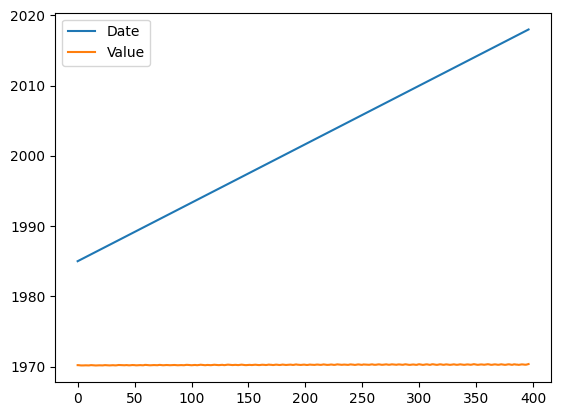

In [ ]:
df.plot();

---
### 2.1 Load and prepare Dataset

In [ ]:
import numpy as np
import torch

def prepare_dataset(dataset, look_back):
    X, y = [], []
    dataset = np.asarray(dataset, dtype=np.float32)
    data_length = len(dataset)
    for i in range(look_back, data_length):
        input_seq = dataset[i - look_back:i]
        output = dataset[i]
        X.append(input_seq)
        y.append(output)

    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(y), dtype=torch.float32)


This function converts a time series into input-output pairs for supervised learning, where each input is a sliding window of `look_back` time steps and the output is the next value. It returns tensors `X` and `y` for training time series models like RNNs or LSTMs.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
import pandas as pd
import numpy as np
import torch

df = pd.read_csv('./Electric_Production.csv', index_col='Date', parse_dates=True)

df = df.astype(np.float32)

look_back = 15

data_length = len(df)
train_data_size = int(data_length * 0.75)

train_data = df.iloc[:train_data_size].values
validation_data = df.iloc[train_data_size:].values

X_train, y_train = prepare_dataset(train_data, look_back)
X_val, y_val = prepare_dataset(validation_data, look_back)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train = X_train.to(device)
y_train = y_train.to(device)
X_val = X_val.to(device)
y_val = y_val.to(device)

print(f"Shape of X_train data -> {X_train.shape}")
print(f"Shape of y_train data -> {y_train.shape}")
print(f"Shape of X_val data -> {X_val.shape}")
print(f"Shape of y_val data -> {y_val.shape}")


Shape of X_train data -> torch.Size([282, 15, 1])
Shape of y_train data -> torch.Size([282, 1])
Shape of X_val data -> torch.Size([85, 15, 1])
Shape of y_val data -> torch.Size([85, 1])


---
---
## 3 Trainer function

In [ ]:
import torch
import copy

def trainer(model, X_train, y_train, X_val, y_val, optimizer, criterion, n_epochs):
    early_stopping_patience = 150
    early_stopping_counter = 0

    valid_loss_min=np.inf
    best_model = copy.deepcopy(model)

    train_losses = []
    val_losses = []

    for epoch in range(n_epochs):
        model.train()

        output_train = model(X_train)
        train_loss = criterion(output_train, y_train)
        train_losses.append(train_loss.item())

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        with torch.no_grad():
            model.eval()
            output_val = model(X_val)
            valid_loss = criterion(output_val, y_val)
            val_losses.append(valid_loss.item())

            if valid_loss <= valid_loss_min:
                best_model = copy.deepcopy(model)
                print(f'Epoch {epoch + 0:01}: Validation loss decreased ({valid_loss_min:.6f} --> {valid_loss:.6f}).')
                valid_loss_min = valid_loss
                early_stopping_counter = 0
            else:
                print(f'Epoch {epoch + 0:01}: Validation loss did not decrease')
                early_stopping_counter += 1

            if early_stopping_counter > early_stopping_patience:
                print('Early stopped at epoch :', epoch)
                break

            print(f'\t Train_Loss: {train_loss:.4f} Val_Loss: {valid_loss:.4f}  BEST VAL Loss: {valid_loss_min:.4f}\n')

    return best_model, train_losses, val_losses


---
---
## 4 RNN

---
### 4.1 Define single RNN cell

In [ ]:
import torch.nn as nn
import numpy as np

class RNNCell(nn.Module):
    def __init__(self, input_size, hidden_size, bias=True, nonlinearity="tanh"):
        super(RNNCell, self).__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.bias = bias
        self.nonlinearity = nonlinearity

        self.x2h = nn.Linear(input_size, hidden_size, bias=bias)
        self.h2h = nn.Linear(hidden_size, hidden_size, bias=bias)

        self.reset_parameters()

    def reset_parameters(self):
        std = 1.0 / np.sqrt(self.hidden_size)
        for w in self.parameters():
            w.data.uniform_(-std, std)

    def forward(self, input, hx=None):
        if hx is None:
            hx = input.new_zeros(input.size(0), self.hidden_size, requires_grad=False)

        gates = self.x2h(input) + self.h2h(hx)

        if self.nonlinearity == "tanh":
            hy = torch.tanh(gates)
        elif self.nonlinearity == "relu":
            hy = torch.relu(gates)
        else:
            raise RuntimeError(
                "Unknown nonlinearity: {}".format(self.nonlinearity))

        return hy



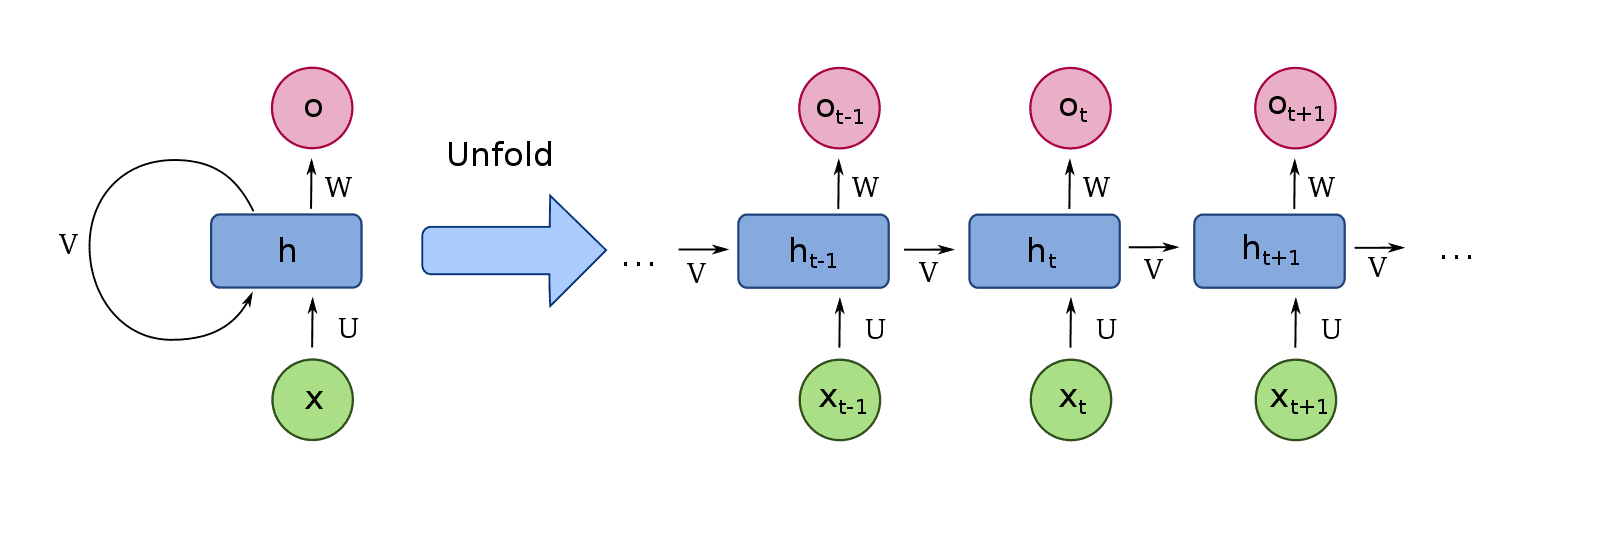

This custom RNN cell is a simplified recurrent unit that processes sequential data. Unlike more complex cells such as LSTM or GRU, this RNN cell computes the new hidden state by applying a linear transformation to the current input and the previous hidden state, followed by a non-linear activation. It serves as an educational example of how basic recurrence can be implemented in PyTorch.

---

## 2. Class Structure and Components

### 2.1. Constructor and Parameter Definitions

- **Input Parameters:**
  - **`input_size`:** Dimensionality of the input vector at each time step.
  - **`hidden_size`:** Size of the hidden state vector.
  - **`bias`:** Boolean flag to determine whether bias terms are added in the linear layers.
  - **`nonlinearity`:** The activation function applied to the computed state; defaults to `"tanh"` but can be set to `"relu"`.

- **Layers Defined:**
  - **`self.x2h`:** A linear layer mapping the input vector (of size `input_size`) to the hidden space (of size `hidden_size`).
  - **`self.h2h`:** A linear layer mapping the previous hidden state (of size `hidden_size`) back into the hidden space.

Both layers combine to compute the new state from the current input and previous hidden state.

### 2.2. Parameter Initialization

The `reset_parameters` method initializes all parameters uniformly. The range for initialization is computed as:

\[
\text{std} = \frac{1}{\sqrt{\text{hidden\_size}}}
\]

Each parameter is then set to a random value in the interval \([-std, std]\). This initialization helps stabilize training by ensuring that initial weight values are not too large.

---

## 3. Forward Pass Details

The `forward` method defines how the cell processes inputs over time:

### 3.1. Handling the Hidden State

- **Initialization:**  
  If no previous hidden state (`hx`) is provided, the cell initializes `hx` as a zero tensor with shape `(batch_size, hidden_size)`. This is done using the same device and data type as the input.

### 3.2. Computing the New Hidden State

- **Linear Transformations:**  
  The method computes two transformations:
  - **Input Contribution:** `self.x2h(input)`
  - **Hidden Contribution:** `self.h2h(hx)`
  
  These contributions are summed to produce the combined activation (often referred to as the "gates" in RNN literature):
  
  ```python
  gates = self.x2h(input) + self.h2h(hx)
  ```

- **Non-linear Activation:**  
  Depending on the value of `self.nonlinearity`, the cell applies:
  - **Tanh Activation:** If `nonlinearity` is `"tanh"`, then:
    
    ```python
    hy = torch.tanh(gates)
    ```
  
  - **ReLU Activation:** If set to `"relu"`, then:
    
    ```python
    hy = torch.relu(gates)
    ```
  
  If an unknown nonlinearity is provided, a `RuntimeError` is raised.

### 3.3. Output

The method returns the new hidden state `hy`, which serves as the updated memory of the RNN cell and can be used in subsequent time steps.

---

## 4. Summary

- **Purpose:**  
  This custom RNN cell demonstrates how to combine current inputs with previous hidden states using linear transformations and non-linear activations.
  
- **Core Components:**  
  - Two linear layers (`x2h` and `h2h`) combine input and hidden information.
  - Parameter initialization ensures stable training.
  - The forward pass computes the new hidden state using the chosen nonlinearity.
  
- **Usage:**  
  This cell can be used in sequence modeling tasks and serves as an educational tool for understanding how recurrent units operate at a low level.



---
### 4.2 RNN model

In [ ]:
import torch.nn as nn

class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, bias, output_size):
        super(SimpleRNN, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_size, num_layers, bias=bias, batch_first=True)

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, input, hx=None):
        out, _ = self.rnn(input, hx)

        out = out[:, -1, :]

        out = self.fc(out)

        return out



The `SimpleRNN` model is designed for sequence processing tasks. It uses PyTorch’s built-in recurrent neural network (RNN) layer to process input sequences and a fully connected (linear) layer to generate the final output. This architecture is suitable for applications such as sequence classification and time series forecasting.

---

## 2. Model Architecture

### 2.1. RNN Layer

- **Module:** `nn.RNN`
- **Function:**  
  The RNN layer processes sequential data by maintaining hidden states over time. At each time step, it updates its hidden state based on the current input and the previous hidden state.
  
- **Key Parameters:**
  - **`input_size`:** Number of features in the input at each time step.
  - **`hidden_size`:** Dimensionality of the hidden state, which captures the sequence’s internal representation.
  - **`num_layers`:** Number of stacked RNN layers, which can help capture complex patterns in the sequence.
  - **`bias`:** Whether to include a bias term in the computations.
  - **`batch_first=True`:** Indicates that the input tensor is expected in the shape `(batch_size, sequence_length, input_size)`. This makes it easier to work with mini-batches in most cases.

### 2.2. Fully Connected (FC) Layer

- **Module:** `nn.Linear`
- **Function:**  
  After processing the sequence with the RNN, the fully connected layer maps the final hidden state (a fixed-size vector) to the desired output dimension.
  
- **Key Parameter:**
  - **`output_size`:** The dimensionality of the model’s final output, e.g., the number of classes for classification or a scalar for regression.

---

## 3. Forward Pass

### 3.1. RNN Processing

- **Input:**  
  The forward method accepts an `input` tensor of shape `(batch_size, sequence_length, input_size)` and an optional initial hidden state `hx`.
  
- **Processing:**  
  The input is passed through the RNN layer:
  ```python
  out, _ = self.rnn(input, hx)
  ```
  - **`out`:** Contains the hidden states for every time step.
  - The underscore (`_`) is used to ignore the final hidden state returned by the RNN, as it is not needed separately.

### 3.2. Final Time Step Extraction

- **Rationale:**  
  For many sequence tasks, only the final time step's hidden state is used for prediction. This hidden state is assumed to encapsulate the information from the entire sequence.
  
- **Extraction:**  
  ```python
  out = out[:, -1, :]
  ```
  This line selects the hidden state from the last time step for each sequence in the batch.

### 3.3. Generating the Output

- **Mapping to Output:**  
  The selected hidden state is passed through the fully connected layer to produce the final output:
  ```python
  out = self.fc(out)
  ```
  
- **Output:**  
  The resulting tensor `out` is returned, representing the model’s prediction for the given input sequence.

---

## 4. Summary

- **Architecture Overview:**  
  The model is composed of a multi-layer RNN that processes sequences and a linear layer that maps the final hidden state to an output.
  
- **Key Flow:**
  1. **Input Sequence:** Provided as a batch of sequences.
  2. **RNN Processing:** The RNN computes hidden states for each time step.
  3. **Final Hidden State Extraction:** The last time step’s hidden state is selected.
  4. **Output Mapping:** The fully connected layer converts this hidden state into the final output.

- **Use Case:**  
  This simple yet powerful model is ideal for tasks where the prediction is based on the entire sequence, such as sequence classification or regression problems in time series data.


---
### 4.3 Train RNN model and plot losses

In [ ]:
SimpleRNN_model = SimpleRNN(input_size=1, hidden_size=50, num_layers=1, bias=True, output_size=1)
SimpleRNN_model.to(device)

SimpleRNN(
  (rnn): RNN(1, 50, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)

In [ ]:
learning_rate = 0.008
n_epochs = 2000
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(SimpleRNN_model.parameters(), lr = learning_rate)

In [ ]:
SimpleRNN_best_model, train_losses, val_losses = trainer(SimpleRNN_model, X_train, y_train, X_val, y_val, optimizer, criterion, n_epochs)

Streaming output truncated to the last 5000 lines.
	 Train_Loss: 221.7906 Val_Loss: 637.6376  BEST VAL Loss: 637.6376

Epoch 334: Validation loss decreased (637.637634 --> 634.433594).
	 Train_Loss: 220.9406 Val_Loss: 634.4336  BEST VAL Loss: 634.4336

Epoch 335: Validation loss decreased (634.433594 --> 631.269775).
	 Train_Loss: 220.1080 Val_Loss: 631.2698  BEST VAL Loss: 631.2698

Epoch 336: Validation loss decreased (631.269775 --> 628.144836).
	 Train_Loss: 219.2925 Val_Loss: 628.1448  BEST VAL Loss: 628.1448

Epoch 337: Validation loss decreased (628.144836 --> 625.058105).
	 Train_Loss: 218.4940 Val_Loss: 625.0581  BEST VAL Loss: 625.0581

Epoch 338: Validation loss decreased (625.058105 --> 622.009277).
	 Train_Loss: 217.7118 Val_Loss: 622.0093  BEST VAL Loss: 622.0093

Epoch 339: Validation loss decreased (622.009277 --> 618.998352).
	 Train_Loss: 216.9461 Val_Loss: 618.9984  BEST VAL Loss: 618.9984

Epoch 340: Validation loss decreased (618.998352 --> 616.024414).
	 Train_Los

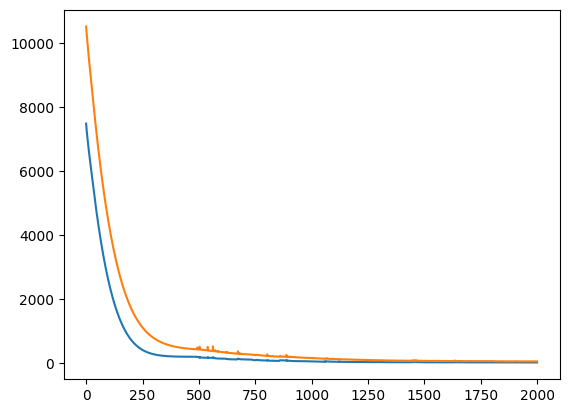

In [ ]:
plt.plot(train_losses, label = 'Train_loss')
plt.plot(val_losses, label = 'validation_loss')
plt.show()

---
### 4.4 Evaluate model on validation data

In [ ]:
val_predict_RNN = SimpleRNN_best_model(X_val)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:716: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1412.)
  result = _VF.rnn_tanh(


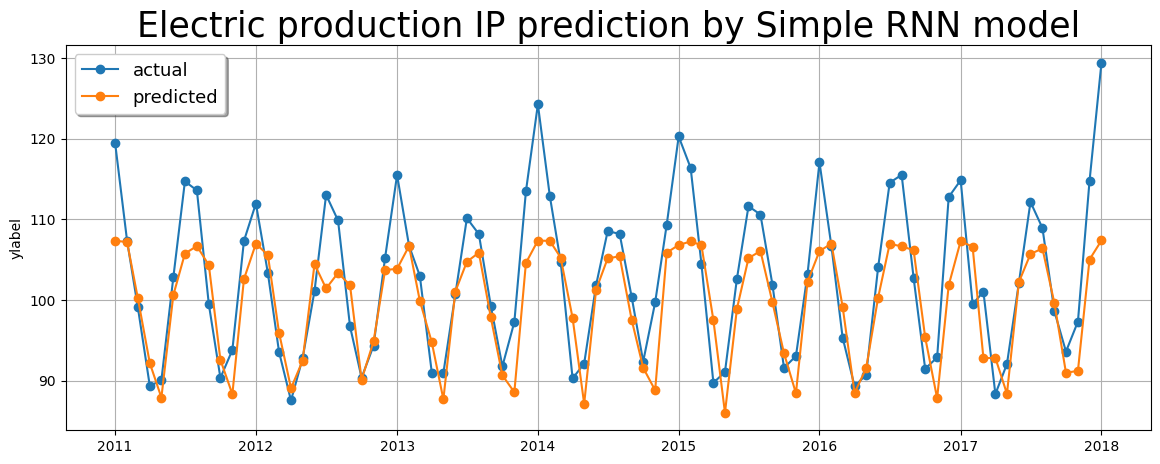

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(df[-len(y_val):].index, y_val.cpu(), label="actual", marker="o")
plt.plot(df[-len(y_val):].index, val_predict_RNN.detach().cpu(), label="predicted", marker="o")
plt.title("Electric production IP prediction by Simple RNN model", fontsize=25)
plt.ylabel("ylabel")
plt.legend(title_fontsize=14, fontsize=13, fancybox=True, shadow=True, frameon=True)
plt.grid()
plt.show()

---
---
## 5 GRU

---
### 5.1 Define single GRU cell

In [ ]:
import torch
import torch.nn as nn
import math

class ModifiedGRUCell(nn.Module):
    def __init__(self, input_dim=10, hidden_dim=20, use_bias=True):
        super(ModifiedGRUCell, self).__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        self.reset_gate = nn.Linear(input_dim + hidden_dim, hidden_dim, bias=use_bias)
        self.update_gate = nn.Linear(input_dim + hidden_dim, hidden_dim, bias=use_bias)
        self.candidate_gate = nn.Linear(input_dim + hidden_dim, hidden_dim, bias=use_bias)

        self._initialize_weights()

    def _initialize_weights(self):
        init_std = 1.0 / math.sqrt(self.hidden_dim)
        for param in self.parameters():
            param.data.uniform_(-init_std, init_std)


    def forward(self, x, h_prev):
        combined = torch.cat((x, h_prev), dim=1)
        r = torch.sigmoid(self.reset_gate(combined))
        z = torch.sigmoid(self.update_gate(combined))

        candidate_input = torch.cat((x, r * h_prev), dim=1)
        n = torch.tanh(self.candidate_gate(candidate_input))

        h_new = (1 - z) * n + z * h_prev
        return h_new


This custom GRU cell class is built as a PyTorch module designed to mimic the behavior of a Gated Recurrent Unit. The constructor initializes the cell with specified input and hidden dimensions, creating three linear layers that serve as the reset, update, and candidate (output) gates. Additionally, the weights of these layers are initialized uniformly using a scaling factor based on the hidden dimension, ensuring that the parameters start within a balanced range.

During the forward pass, the cell receives the current input and the previous hidden state, which are concatenated together. This combined tensor is processed through the reset and update gates, where sigmoid activations generate values between 0 and 1. These values represent the degree to which the past hidden state should be reset or maintained. To compute the candidate hidden state, the code applies the reset gate to modulate the previous hidden state before concatenating it again with the input. The candidate hidden state is then obtained by passing this new combination through the candidate gate with a tanh activation, introducing non-linearity.

Finally, the new hidden state is computed by blending the candidate hidden state with the previous hidden state using the update gate as a balancing factor. Specifically, the candidate state is weighted by (1 - update value) while the previous state is weighted by the update value, allowing the GRU cell to decide dynamically how much of the new information to incorporate versus retaining past information. This mechanism makes the cell effective for handling sequential data by adaptively capturing temporal dependencies.

---
### 5.2 GRU model

In [ ]:
import torch.nn as nn

class CustomGRUNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_count, use_bias, output_dim):

        super(CustomGRUNet, self).__init__()
        self.gru_layer = nn.GRU(input_dim, hidden_dim, layer_count, bias=use_bias, batch_first=True)
        self.fc_layer = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, h0=None):
        gru_out, _ = self.gru_layer(x, h0)
        last_time_step = gru_out[:, -1, :]
        output = self.fc_layer(last_time_step)

        return output


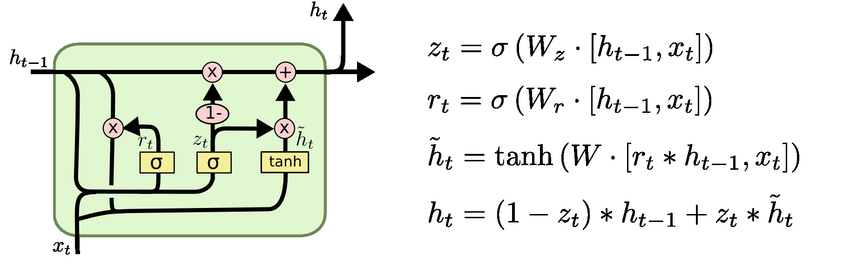
## Introduction
Gated Recurrent Units (GRUs) are a type of recurrent neural network (RNN) architecture designed to effectively capture long-term dependencies in sequential data. Introduced as a simpler alternative to Long Short-Term Memory (LSTM) networks, GRUs address the vanishing gradient problem inherent in standard RNNs by incorporating gating mechanisms that regulate the flow of information. This design not only enhances training stability but also reduces the computational complexity by utilizing fewer parameters compared to LSTMs.

## GRU Architecture and Mechanisms
The GRU architecture centers around two primary gates: the **reset gate** and the **update gate**. These gates modulate how information is combined from the current input and the previous hidden state. Specifically:
- **Reset Gate (r):**  
  The reset gate determines how much of the past information to forget. It is computed by applying a sigmoid function to a linear combination of the current input and the previous hidden state. This gate allows the network to drop irrelevant past information when necessary.
  
- **Update Gate (z):**  
  The update gate controls the balance between incorporating new information and retaining the old hidden state. It, too, is generated using a sigmoid function. This gate ensures that the network maintains long-term dependencies by choosing to keep a portion of the previous hidden state.

The candidate activation (often denoted as \( n \) or \( \tilde{h} \)) is computed by first modulating the previous hidden state with the reset gate and then combining it with the current input. This candidate is then passed through a hyperbolic tangent (tanh) activation function, adding non-linearity to the transformation. Finally, the new hidden state is calculated as a weighted sum of the candidate activation and the previous hidden state, with the update gate determining the weights:
  
$$
\begin{aligned}
r &= \sigma(W_r [x, h]) \\
z &= \sigma(W_z [x, h]) \\
\tilde{h} &= \tanh(W [x, r \odot h]) \\
h_{\text{new}} &= (1 - z) \odot \tilde{h} + z \odot h
\end{aligned}
$$


This formulation allows the GRU to flexibly decide at each time step how much new information to incorporate versus how much of the old state to preserve.

## Advantages, Applications, and Conclusion
One of the main advantages of GRUs is their relative simplicity: with fewer gates than LSTMs, they require fewer parameters and are computationally more efficient, which can be beneficial in tasks with limited training data or when fast inference is needed. GRUs have proven effective in a wide range of applications, including natural language processing, time series forecasting, and speech recognition, where modeling sequential dependencies is critical.

In conclusion, GRUs provide an efficient yet powerful mechanism for learning from sequential data by dynamically managing the flow of information through their reset and update gates. This capability not only mitigates issues like the vanishing gradient but also ensures that the network can adaptively capture both short-term and long-term dependencies in data. As a result, GRUs continue to be a popular choice for many sequence modeling tasks in the deep learning community.

---
### 5.3 Train GRU model and plot losses

In [ ]:
GRU_model = GRU(input_size=1, hidden_size=50, num_layers=1, bias=True, output_size=1)
GRU_model.to(device)

GRU(
  (gru): GRU(1, 50, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)

In [ ]:
learning_rate = 0.008
n_epochs = 2000
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(GRU_model.parameters(), lr = learning_rate)

In [ ]:
GRU_best_model, train_losses, val_losses = trainer(GRU_model, X_train, y_train, X_val, y_val, optimizer, criterion, n_epochs)

Streaming output truncated to the last 5000 lines.
	 Train_Loss: 230.6355 Val_Loss: 669.5401  BEST VAL Loss: 669.5401

Epoch 334: Validation loss decreased (669.540100 --> 665.938232).
	 Train_Loss: 229.6038 Val_Loss: 665.9382  BEST VAL Loss: 665.9382

Epoch 335: Validation loss decreased (665.938232 --> 662.380676).
	 Train_Loss: 228.5929 Val_Loss: 662.3807  BEST VAL Loss: 662.3807

Epoch 336: Validation loss decreased (662.380676 --> 658.868103).
	 Train_Loss: 227.6027 Val_Loss: 658.8681  BEST VAL Loss: 658.8681

Epoch 337: Validation loss decreased (658.868103 --> 655.398743).
	 Train_Loss: 226.6327 Val_Loss: 655.3987  BEST VAL Loss: 655.3987

Epoch 338: Validation loss decreased (655.398743 --> 651.972412).
	 Train_Loss: 225.6825 Val_Loss: 651.9724  BEST VAL Loss: 651.9724

Epoch 339: Validation loss decreased (651.972412 --> 648.589417).
	 Train_Loss: 224.7517 Val_Loss: 648.5894  BEST VAL Loss: 648.5894

Epoch 340: Validation loss decreased (648.589417 --> 645.247559).
	 Train_Los

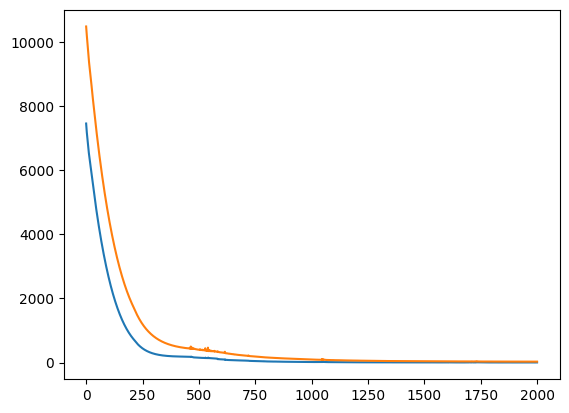

In [ ]:
plt.plot(train_losses, label = 'Train_loss')
plt.plot(val_losses, label = 'validation_loss')
plt.show()

---
### 5.4 Evaluate model on validation data

In [ ]:
val_predict_GRU = GRU_best_model(X_val)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:1393: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1412.)
  result = _VF.gru(


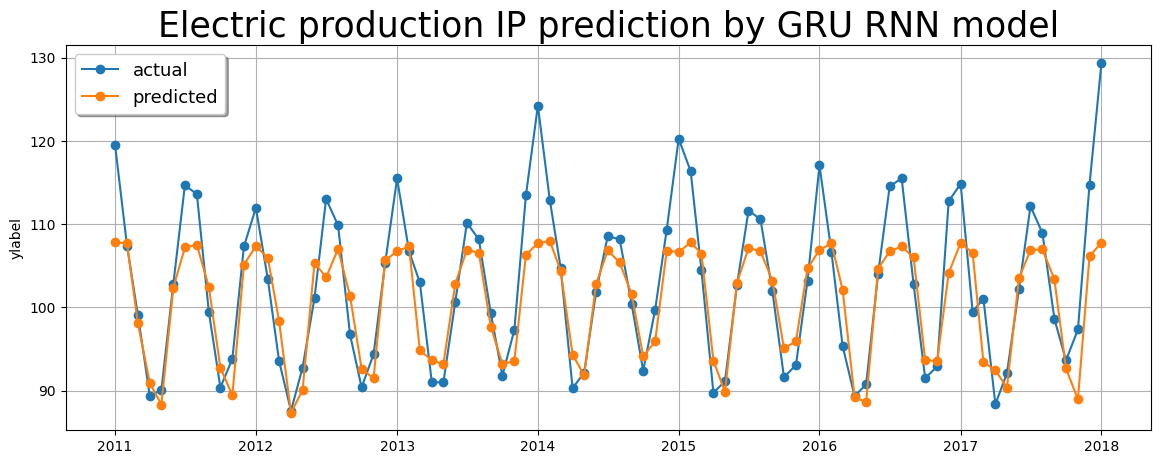

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(df[-len(y_val):].index, y_val.cpu(), label="actual", marker="o")
plt.plot(df[-len(y_val):].index, val_predict_GRU.detach().cpu(), label="predicted", marker="o")
plt.title("Electric production IP prediction by GRU RNN model", fontsize=25)
plt.ylabel("ylabel")
plt.legend(title_fontsize=14, fontsize=13, fancybox=True, shadow=True, frameon=True)
plt.grid()
plt.show()

---
---
## 6 LSTM

---
### 6.1 Define single LSTM cell

In [ ]:
import torch
import torch.nn as nn
import numpy as np

class CustomLSTMCell(nn.Module):
    def __init__(self, input_dim=10, hidden_dim=20, use_bias=True):
        super(CustomLSTMCell, self).__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        self.gate_forget = nn.Linear(input_dim + hidden_dim, hidden_dim, bias=use_bias)
        self.gate_input = nn.Linear(input_dim + hidden_dim, hidden_dim, bias=use_bias)
        self.gate_candidate = nn.Linear(input_dim + hidden_dim, hidden_dim, bias=use_bias)
        self.gate_output = nn.Linear(input_dim + hidden_dim, hidden_dim, bias=use_bias)

        self.initialize_weights()

    def initialize_weights(self):
        init_std = 1.0 / np.sqrt(self.hidden_dim)
        for param in self.parameters():
            param.data.uniform_(-init_std, init_std)

    def forward(self, x, state=None):
        if state is None:
            h_prev = x.new_zeros(x.size(0), self.hidden_dim, requires_grad=False)
            c_prev = x.new_zeros(x.size(0), self.hidden_dim, requires_grad=False)
        else:
            h_prev, c_prev = state

        combined_input = torch.cat((x, h_prev), dim=1)

        forget_val = torch.sigmoid(self.gate_forget(combined_input))
        input_val = torch.sigmoid(self.gate_input(combined_input))
        candidate_val = torch.tanh(self.gate_candidate(combined_input))

        c_new = forget_val * c_prev + input_val * candidate_val

        output_val = torch.sigmoid(self.gate_output(combined_input))
        h_new = output_val * torch.tanh(c_new)

        return h_new, c_new




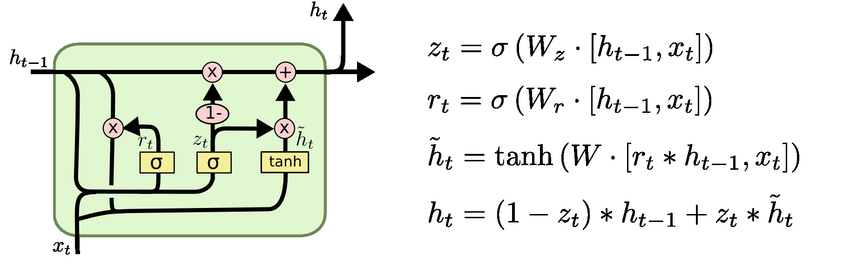
## 1. Introduction

This report explains a custom implementation of an LSTM cell using PyTorch. The LSTM (Long Short-Term Memory) cell is a building block for recurrent neural networks (RNNs) that can capture long-term dependencies in sequential data. This implementation is intended for educational and experimental use in a Colab environment.

---

## 2. Class Overview

The `LSTMCell` class inherits from `torch.nn.Module`, making it a PyTorch module. It encapsulates all the operations necessary to compute the LSTM's output for a given time step.

### Key Parameters

- **input_length**: Number of features in the input vector.
- **hidden_size**: Dimensionality of the hidden state and cell state.
- **bias**: Flag indicating whether to include bias terms in the linear layers.

---

## 3. Layer Definitions

The LSTM cell defines four separate linear layers corresponding to the four key gates:

1. **Forget Gate (`forget_gate`)**:  
   - **Purpose:** Determines which parts of the previous cell state to discard.  
   - **Operation:** Applies a linear transformation followed by a sigmoid activation to decide what to forget.

2. **Input Gate (`input_gate`)**:  
   - **Purpose:** Controls how much new information from the current input should be added to the cell state.  
   - **Operation:** Uses a linear transformation and a sigmoid activation.

3. **Cell Gate (`cell_gate`)**:  
   - **Purpose:** Generates new candidate values that can be added to the cell state.  
   - **Operation:** Uses a linear transformation followed by a tanh activation to create new content.

4. **Output Gate (`output_gate`)**:  
   - **Purpose:** Determines the output hidden state based on the updated cell state.  
   - **Operation:** Applies a linear transformation and a sigmoid activation.

Each gate receives as input the concatenation of the current input vector and the previous hidden state, ensuring that both the new and past information are considered.

---

## 4. Parameter Initialization

The `reset_parameters` method initializes all the parameters (weights) of the linear layers uniformly. The range is determined by:

\[
\text{range} = \left[-\frac{1}{\sqrt{\text{hidden\_size}}}, \frac{1}{\sqrt{\text{hidden\_size}}}\right]
\]

This initialization helps maintain gradient stability during training.

---

## 5. Forward Pass Mechanics

The `forward` method defines how data flows through the LSTM cell for each time step.

### 5.1. Initial State Setup

- **No Previous States:**  
  If no previous hidden state (`hx`) and cell state (`cx`) are provided, they are initialized to zeros with the appropriate dimensions.

### 5.2. Input Concatenation

- **Concatenated Input:**  
  The method concatenates the current input `x` with the previous hidden state `hx` along the feature dimension. This combined tensor is then used as input for all four gates.

### 5.3. Gate Computations

1. **Forget Gate (`fg`):**  
   - The concatenated input is passed through the `forget_gate` linear layer.
   - A sigmoid activation is applied to yield values between 0 and 1.

2. **Input Gate (`ig`):**  
   - Similarly, the concatenated input is processed by the `input_gate` layer.
   - A sigmoid activation determines the amount of new information to add.

3. **Cell Gate (`cg`):**  
   - The cell candidate is computed by passing the concatenated input through the `cell_gate` layer followed by a tanh activation.
   - This produces new candidate values ranging from -1 to 1.

### 5.4. Updating the Cell State

- **Cell State Calculation:**  
  The new cell state (`cx`) is updated by combining the old cell state (multiplied by the forget gate values) and the candidate cell values (scaled by the input gate).


### 5.5. Computing the Hidden State

- **Output Gate:**  
  The output gate processes the concatenated input, and its sigmoid output scales the updated cell state (after applying tanh) to produce the new hidden state (`hx`).

\[
\text{new\_hx} = \text{og} \times \tanh(\text{new\_cx})
\]

### 5.6. Return Values

- The cell returns a tuple `(hx, cx)`, containing the updated hidden state and cell state.


---
### 6.2 LSTM model

In [ ]:
import torch.nn as nn

class CustomLSTMNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_count, use_bias, output_dim):
        super(CustomLSTMNet, self).__init__()
        self.lstm_layer = nn.LSTM(input_dim, hidden_dim, layer_count, bias=use_bias, batch_first=True)
        self.linear_layer = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, initial_states=None):
        lstm_out, _ = self.lstm_layer(x, initial_states)
        final_timestep_output = lstm_out[:, -1, :]
        output = self.linear_layer(final_timestep_output)

        return output


This model leverages PyTorch’s built-in `nn.LSTM` for sequential data processing and a linear layer (`nn.Linear`) for mapping the final hidden state to the output. It is well-suited for tasks like sequence classification or time series prediction.

## . Model Components

- **LSTM Layer**  
  - **Input:** Sequences with shape `(batch_size, sequence_length, input_size)`.  
  - **Function:** Captures temporal dependencies using one or more LSTM layers.  
  - **Parameters:** `input_size`, `hidden_size`, `num_layers`, `bias`, with `batch_first=True`.

- **Fully Connected Layer**  
  - **Input:** Hidden state from the last time step.  
  - **Function:** Maps the hidden representation to the desired `output_size`.

## . Forward Pass

1. **Sequence Processing:**  
   The input is passed through the LSTM, which outputs hidden states for all time steps.
   
2. **Time Step Extraction:**  
   The hidden state from the last time step is extracted using `out[:, -1, :]`.

3. **Output Generation:**  
   The final hidden state is fed into the fully connected layer to produce the model's prediction.



---
### 6.3 Train LSTM model and plot losses

In [ ]:
LSTM_model = CustomLSTMNet(input_size=1, hidden_size=50, num_layers=1, bias=True, output_size=1)
LSTM_model.to(device)

LSTM(
  (lstm): LSTM(1, 50, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)

In [ ]:
learning_rate = 0.008
n_epochs = 2000
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(LSTM_model.parameters(), lr = learning_rate)

In [ ]:
LSTM_best_model, train_losses, val_losses = trainer(LSTM_model, X_train, y_train, X_val, y_val, optimizer, criterion, n_epochs)

Streaming output truncated to the last 5000 lines.
	 Train_Loss: 300.0194 Val_Loss: 873.1767  BEST VAL Loss: 873.1767

Epoch 334: Validation loss decreased (873.176697 --> 868.051147).
	 Train_Loss: 298.0327 Val_Loss: 868.0511  BEST VAL Loss: 868.0511

Epoch 335: Validation loss decreased (868.051147 --> 862.977234).
	 Train_Loss: 296.0763 Val_Loss: 862.9772  BEST VAL Loss: 862.9772

Epoch 336: Validation loss decreased (862.977234 --> 857.954529).
	 Train_Loss: 294.1501 Val_Loss: 857.9545  BEST VAL Loss: 857.9545

Epoch 337: Validation loss decreased (857.954529 --> 852.983643).
	 Train_Loss: 292.2538 Val_Loss: 852.9836  BEST VAL Loss: 852.9836

Epoch 338: Validation loss decreased (852.983643 --> 848.062500).
	 Train_Loss: 290.3867 Val_Loss: 848.0625  BEST VAL Loss: 848.0625

Epoch 339: Validation loss decreased (848.062500 --> 843.191223).
	 Train_Loss: 288.5487 Val_Loss: 843.1912  BEST VAL Loss: 843.1912

Epoch 340: Validation loss decreased (843.191223 --> 838.370239).
	 Train_Los

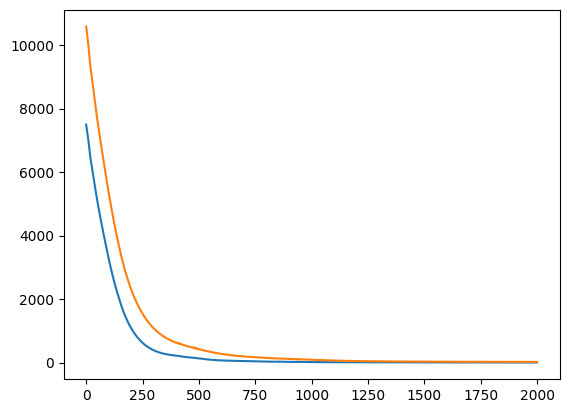

In [ ]:
plt.plot(train_losses, label = 'Train_loss')
plt.plot(val_losses, label = 'validation_loss')
plt.show()

---
### 6.4 Evaluate model on validation data

In [ ]:
val_predict_LSTM = LSTM_best_model(X_val)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:1124: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1412.)
  result = _VF.lstm(


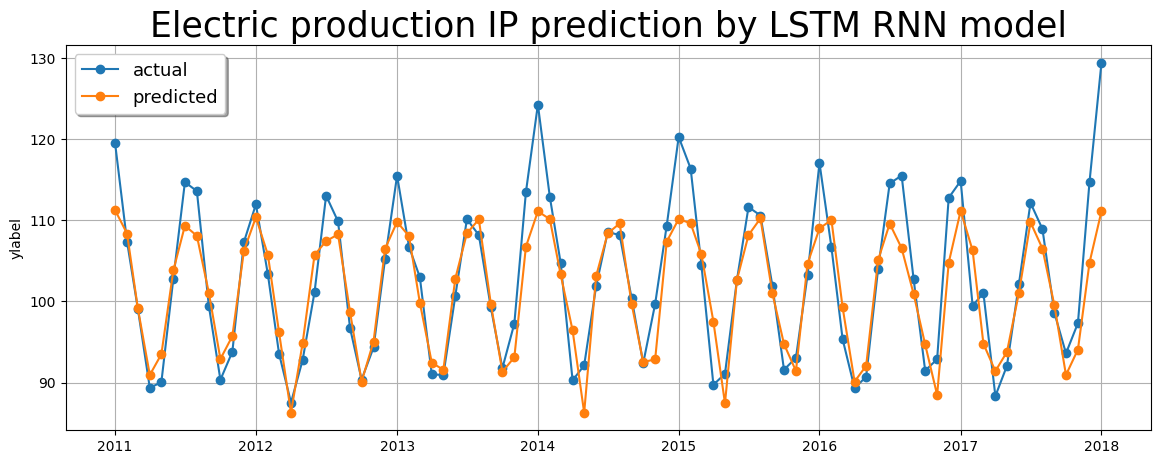

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(df[-len(y_val):].index, y_val.cpu(), label="actual", marker="o")
plt.plot(df[-len(y_val):].index, val_predict_LSTM.detach().cpu(), label="predicted", marker="o")
plt.title("Electric production IP prediction by LSTM RNN model", fontsize=25)
plt.ylabel("ylabel")
plt.legend(title_fontsize=14, fontsize=13, fancybox=True, shadow=True, frameon=True)
plt.grid()
plt.show()

---
---
## 7 Comaprison

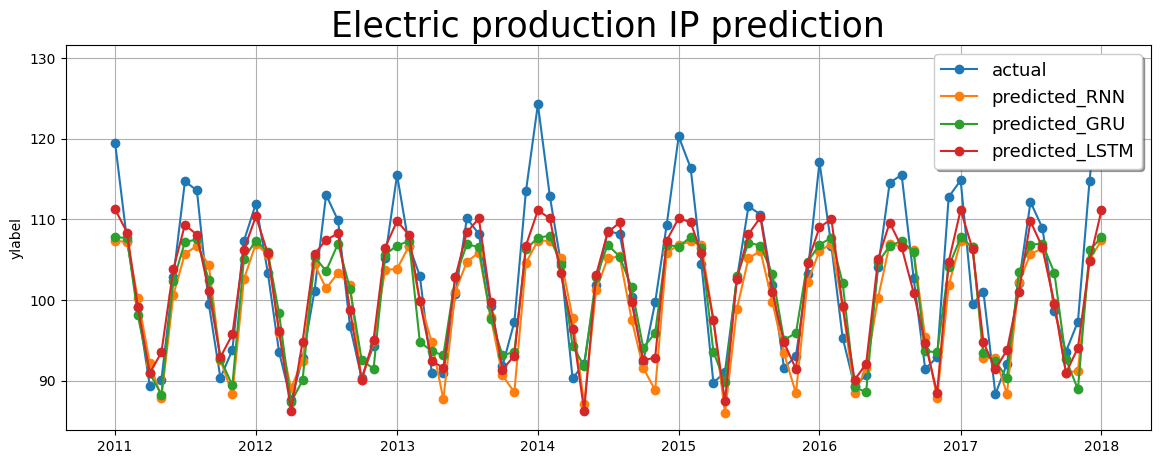

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(df[-len(y_val):].index, y_val.cpu(), label="actual", marker="o")
plt.plot(df[-len(y_val):].index, val_predict_RNN.detach().cpu(), label="predicted_RNN", marker="o")
plt.plot(df[-len(y_val):].index, val_predict_GRU.detach().cpu(), label="predicted_GRU", marker="o")
plt.plot(df[-len(y_val):].index, val_predict_LSTM.detach().cpu(), label="predicted_LSTM", marker="o")
plt.title("Electric production IP prediction", fontsize=25)
plt.ylabel("ylabel")
plt.legend(title_fontsize=14, fontsize=13, fancybox=True, shadow=True, frameon=True)
plt.grid()
plt.show()


<b>1-Rank these architectures based on their performance?

2-Why are they ranked in this order?

3-Run the notebook again with look_back = 15.
write about the difference in the comparison plot and the possible cause for that difference.</b>



## Abstract
This report provides an in-depth analysis of three recurrent neural network (RNN) architectures—LSTM, GRU, and vanilla RNN—in terms of their performance in handling sequence prediction tasks. It also examines the effect of adjusting the lookback period on model performance. The analysis reveals that the LSTM model outperforms both GRU and vanilla RNNs due to its sophisticated gating mechanism that effectively manages long-term dependencies. Moreover, reducing the lookback period from 60 to 15 timesteps appears to improve the model's ability to capture short-term trends and reduces the risk of overfitting.

## Introduction
Recurrent neural networks are widely used for modeling temporal data due to their ability to capture sequential dependencies. However, the traditional vanilla RNN suffers from the vanishing gradient problem, which limits its ability to learn long-term dependencies. To address these limitations, advanced architectures such as Long Short-Term Memory (LSTM) and Gated Recurrent Unit (GRU) were introduced. This report evaluates the performance of these architectures, ranking them in order of effectiveness, and discusses how modifying the lookback period—a hyperparameter that determines the number of past timesteps considered for making a prediction—impacts model performance.

## Architecture Comparison

### LSTM (Long Short-Term Memory)
LSTM networks incorporate a cell state and multiple gates (input, forget, and output gates) that meticulously control the flow of information.  
- **Advantages**:  
  - **Long-Term Dependency Handling**: The gating mechanism enables LSTM to retain relevant information over long periods, making it suitable for complex tasks with extended temporal dependencies.  
  - **Flexibility**: The design allows fine-grained control over what to remember or forget at each timestep.

### GRU (Gated Recurrent Unit)
GRUs simplify the gating mechanism by combining certain gates and omitting the explicit cell state found in LSTMs.  
- **Advantages**:  
  - **Computational Efficiency**: With fewer parameters, GRUs offer faster training and inference while still mitigating the vanishing gradient issue.  
  - **Balance Between Complexity and Performance**: Although slightly less powerful than LSTMs for tasks with long-term dependencies, GRUs typically outperform vanilla RNNs.

### Vanilla RNN (Recurrent Neural Network)
Vanilla RNNs use a straightforward recurrent structure without specialized gates, making them prone to issues like the vanishing gradient problem.  
- **Disadvantages**:  
  - **Limited Long-Term Memory**: The lack of gating mechanisms makes it challenging for vanilla RNNs to capture and maintain long-term dependencies effectively.

## Impact of Lookback Period

### Temporal Dependencies and Lookback Window
- **Lookback Period Definition**:  
  The lookback period specifies the number of previous timesteps that the model considers when making a prediction.  
- **Short vs. Long Lookback**:  
  If the underlying process primarily depends on recent information (short-term dependencies), a smaller lookback (e.g., 15 timesteps) may provide a better signal-to-noise ratio. Conversely, a longer lookback (e.g., 60 timesteps) might introduce unnecessary complexity and noise.

### Overfitting Concerns
- **Model Complexity**:  
  A longer lookback period increases the input sequence length, which in turn raises the risk of overfitting—particularly when the dataset is small (around 400 entries).  
- **Performance Improvement**:  
  Reducing the lookback period simplifies the model's learning task by limiting the amount of historical data it needs to process. This reduction in complexity often results in lower loss values during training and improved generalization on validation data.

### Data Characteristics
- **Nature of the Data**:  
  In scenarios such as electric production forecasting, the most recent events (e.g., weather conditions, demand fluctuations) tend to have a more significant impact on future values. Therefore, focusing on a shorter lookback window allows the model to capture the most relevant trends and patterns.

## Conclusion
The analysis confirms that, in terms of performance, LSTM networks lead, followed by GRU and then vanilla RNNs. The superior performance of LSTM models is largely due to their robust gating mechanisms, which enable effective handling of long-term dependencies. Additionally, reducing the lookback period can improve model performance by better capturing short-term trends, reducing the risk of overfitting, and aligning with the data's intrinsic temporal characteristics. This report underscores the importance of selecting the appropriate architecture and hyperparameters, such as the lookback period, based on the specific requirements and nature of the dataset.